In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from fismi import ismiReplication as fismi
from fismi import utils

In [2]:
# Import data
niv = '4'

# HICP All Items
colHicp = "INX"

# Unchained other items 
dfICP = pd.read_parquet(f"input/USItemsLvl{niv}.parquet")
dfW = pd.read_parquet(f"input/USnormedWeightsLvl{niv}.parquet") 

In [3]:
# We compute inflation rates on Unchained items - 12-month inflation rate (deals mostly with seasonality) - monthly frequency
dfInflation = np.log(dfICP).diff(12)[12:]
InflTot = dfInflation["Personal consumption expenditures"].to_frame()
dfInflation = dfInflation.drop("Personal consumption expenditures",axis=1)

In [4]:
dfInflation = dfInflation.loc[:, ~dfInflation.columns.isin([
        "Internet access (72)",
        "Video and audio streaming and rental"
    ])]
dfInflation

LineDescription,Accessories and parts,Accounting and other business services,Admissions to specified spectator amusements,Air transportation (64),"Amusement parks, campgrounds, and related recreational services",Beer,Bicycles and accessories,"Cable, satellite, and other live television services",Carpets and other floor coverings,Casino gambling,...,Used autos,Used light trucks,Veterinary and other services for pets,Video and audio equipment,Watches,Water supply and sanitation (25),Water transportation (65),Window coverings,Wine,Women's and girls' clothing (10)
TIME_PERIOD,,,,,,,,,,,,,,,,,,,,,
1960-01-01,0.040929,0.018999,0.075148,0.044633,0.032635,0.019247,0.011547,0.382678,0.016010,0.012351,...,0.027271,0.046771,-0.001548,0.004770,0.002262,0.035445,-0.013191,0.043281,0.019535,-0.005131
1960-02-01,0.040875,0.031215,0.078806,0.052515,0.034351,0.019195,0.010265,0.117783,0.018088,0.014098,...,0.026107,0.060764,0.018082,0.003190,-0.000026,0.035107,0.018881,0.056556,0.024784,0.004878
1960-03-01,0.036158,0.038014,0.069760,0.064559,0.035772,0.016813,0.012279,-0.223170,0.025843,0.015096,...,0.012537,0.001990,0.032528,0.003145,-0.000079,0.034885,0.002483,0.067197,0.022226,0.004863
1960-04-01,0.036185,0.026881,0.062672,0.072028,0.034560,0.019046,0.013333,-0.154151,0.019854,0.019168,...,-0.019721,-0.042738,0.021195,0.003247,-0.002104,0.034535,0.013356,0.068828,0.020027,0.006694
1960-05-01,0.038218,0.025770,0.056840,0.079380,0.034430,0.016722,0.012715,0.094690,0.018080,0.018076,...,-0.027598,-0.046151,0.012309,0.001686,-0.002156,0.033520,0.029001,0.071222,0.019942,0.004719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-01,0.064367,-0.019294,-0.003296,0.104917,0.006947,0.019207,0.054566,0.001732,0.066788,0.033247,...,-0.038079,-0.034030,0.056469,0.053830,0.068041,0.046581,-0.008330,0.065975,-0.014994,0.051348
2026-04-01,0.042920,-0.009662,-0.007379,0.122269,0.006793,0.021309,0.041657,0.015787,0.051496,0.037415,...,-0.029792,-0.028854,0.055328,0.041014,0.084323,0.046276,-0.011941,0.078949,-0.010140,0.049044
2026-05-01,0.025765,0.021576,-0.002130,0.154729,0.019727,0.028496,0.045288,0.013772,0.029028,0.041326,...,-0.020599,-0.022465,0.052677,0.022210,0.085372,0.046274,-0.041028,0.052418,-0.005871,0.046034


In [5]:
# Call estimates
df_shocks, aCoef, rhoCoef = fismi.twoStepsAr(dfInflation, rolling_window=120)
posItems, negItems, posIsmi, negIsmi, ismIndex = fismi.replicateIsmi(dfInflation, df_shocks, dfW)

# Merge
ismIndex = ismIndex.to_frame().merge(
    InflTot,
    how="left",
    left_index=True,
    right_index=True)

Step 1 : Estimate 129 AR(1) on a 120 month rolling window...
Step 2 : Compute inflation momentum and aggregate...
Done


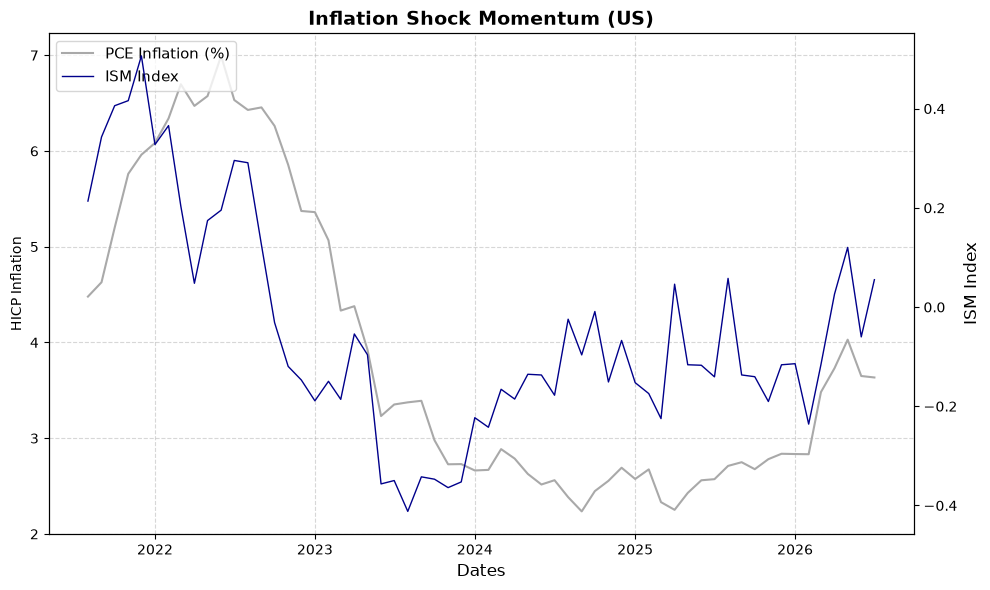

In [6]:
# Plot last 5 years
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (HICP inflation - 12-month) ---
ax1.plot(
    ismIndex.loc[ismIndex.index[-12*5:], "Personal consumption expenditures"] * 100,
    label="PCE Inflation (%)",
    color="darkgrey",
    linewidth=1.5,
)

ax1.set_xlabel("Dates", fontsize=12)
ax1.set_ylabel("HICP Inflation")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Right axis (AR coefficients) ---
ax2 = ax1.twinx()

ax2.plot(
    ismIndex.loc[ismIndex.index[-12*5:], "ISMIndex"],
    label="ISM Index",
    color="darkblue",
    linewidth=1,
)

ax2.set_ylabel("ISM Index", fontsize=12)
ax2.tick_params(axis="y")

# --- Title, legend ---
plt.title("Inflation Shock Momentum (US)", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=11)

plt.tight_layout()
plt.show()

In [7]:
# Compare with Shapiro
ShapiroResults = pd.read_excel("ismi_data.xlsx", "k3_AR1")
# Convert the dates
ShapiroResults["date"] = pd.to_datetime(ShapiroResults["date"])
ShapiroResults = ShapiroResults.set_index("date")
ShapiroResults

,ismi_headline_ar1_k3,ismi_headline_positive_ar1_k3,ismi_headline_negative_ar1_k3,ismi_core_ar1_k3,ismi_core_positive_ar1_k3,ismi_core_negative_ar1_k3,ismi_goods_positive_ar1_k3,ismi_goods_negative_ar1_k3,ismi_services_positive_ar1_k3,ismi_services_negative_ar1_k3,ismi_housing_positive_ar1_k3,ismi_housing_negative_ar1_k3,ismi_coregoods_positive_ar1_k3,ismi_coregoods_negative_ar1_k3,ismi_goods_ar1_k3,ismi_services_ar1_k3,ismi_housing_ar1_k3,ismi_coregoods_ar1_k3
date,,,,,,,,,,,,,,,,,,
1969-01-01,0.188,0.227,0.039,0.251,0.290,0.038,0.192,0.000,0.262,0.078,0.000,0.0,0.312,0.000,0.192,0.184,0.000,0.312
1969-02-01,0.209,0.227,0.018,0.283,0.292,0.010,0.186,0.005,0.270,0.031,0.000,0.0,0.305,0.004,0.180,0.239,0.000,0.301
1969-03-01,0.201,0.209,0.008,0.214,0.215,0.001,0.251,0.014,0.166,0.001,0.000,0.0,0.277,0.000,0.237,0.165,0.000,0.277
1969-04-01,0.318,0.326,0.008,0.365,0.365,0.001,0.363,0.015,0.288,0.001,0.037,0.0,0.462,0.000,0.348,0.287,0.037,0.462
1969-05-01,0.403,0.407,0.004,0.327,0.332,0.005,0.566,0.008,0.243,0.000,0.037,0.0,0.497,0.013,0.558,0.243,0.037,0.484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-01,0.108,0.175,0.067,0.116,0.191,0.075,0.190,0.128,0.169,0.040,0.000,0.0,0.247,0.180,0.061,0.129,0.000,0.067
2026-04-01,-0.031,0.071,0.102,-0.039,0.075,0.114,0.139,0.224,0.041,0.047,0.000,0.0,0.177,0.318,-0.084,-0.006,0.000,-0.141
2026-05-01,-0.066,0.075,0.142,-0.087,0.065,0.152,0.115,0.229,0.057,0.102,0.000,0.0,0.143,0.315,-0.114,-0.045,0.000,-0.172


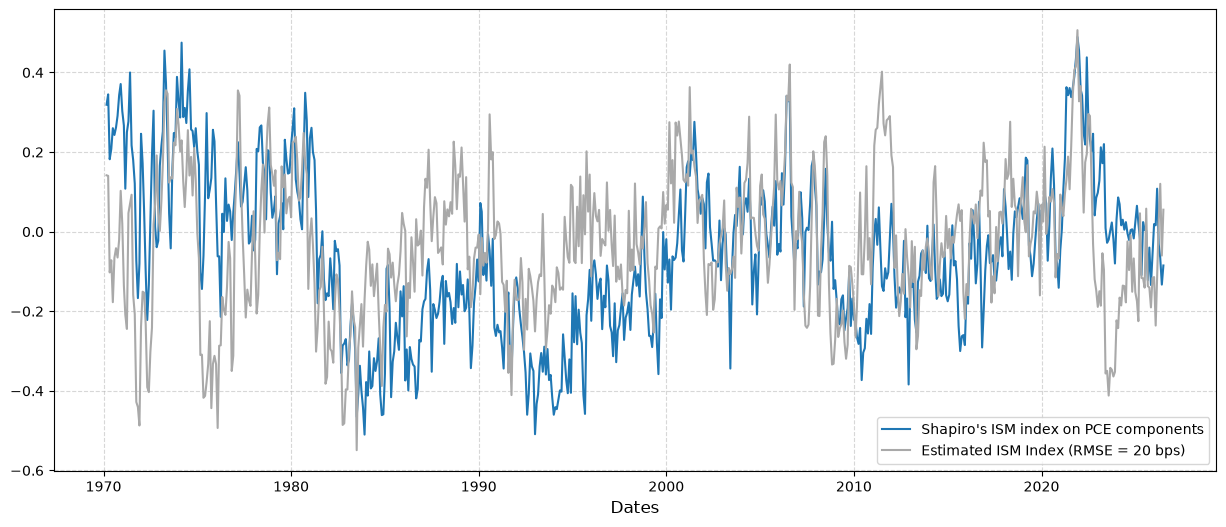

In [8]:
# Compare headline series 
AllSeries = ismIndex.merge(
    ShapiroResults["ismi_headline_ar1_k3"],
    how="left",
    right_index=True,
    left_index=True
)

# Compute RMSE
RMSE = utils.rmse(AllSeries["ismi_headline_ar1_k3"].values, AllSeries["ISMIndex"].values)

fig, ax = plt.subplots(figsize=(15, 6))
x_axis = AllSeries.index
ax.plot(
    x_axis,
    AllSeries["ismi_headline_ar1_k3"].values,
    # color="orange",
    label="Shapiro's ISM index on PCE components",
    linewidth=1.5,
)

ax.plot(
    x_axis,
    AllSeries["ISMIndex"].values,
    label=f"Estimated ISM Index (RMSE = {RMSE*100:.0f} bps)",
    color="darkgrey",
    linewidth=1.5,
)

ax.legend()
ax.set_xlabel("Dates", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

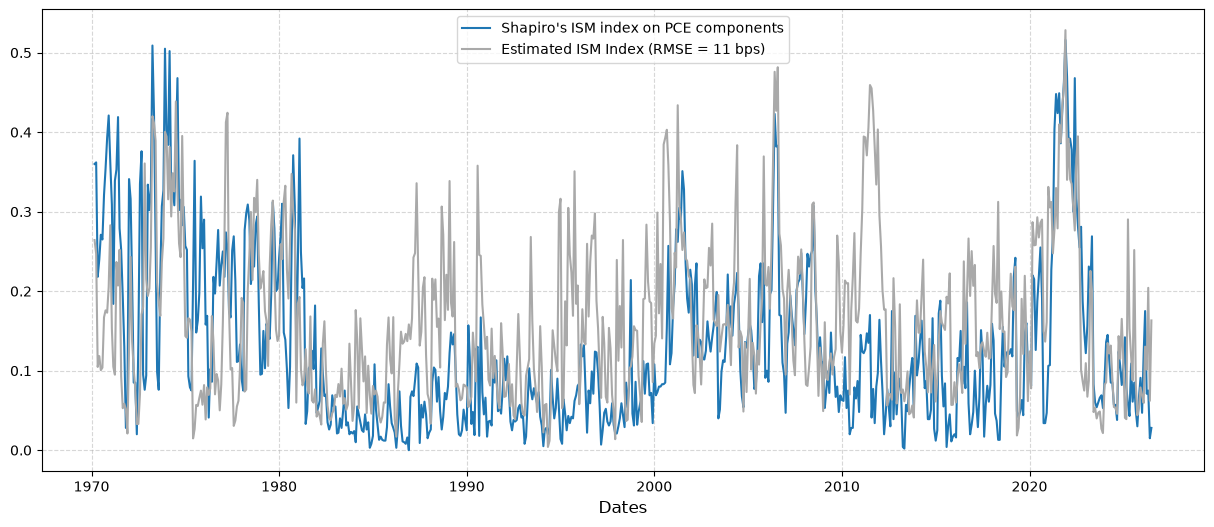

In [9]:
# Compare headline positive series 
AllSeries = posIsmi.to_frame().merge(
    ShapiroResults["ismi_headline_positive_ar1_k3"],
    how="left",
    right_index=True,
    left_index=True
)

# Compute RMSE
RMSE = utils.rmse(AllSeries["ismi_headline_positive_ar1_k3"].values, AllSeries["ISMI+"].values)

fig, ax = plt.subplots(figsize=(15, 6))
x_axis = AllSeries.index
ax.plot(
    x_axis,
    AllSeries["ismi_headline_positive_ar1_k3"].values,
    # color="orange",
    label="Shapiro's ISM index on PCE components",
    linewidth=1.5,
)

ax.plot(
    x_axis,
    AllSeries["ISMI+"].values,
    label=f"Estimated ISM Index (RMSE = {RMSE*100:.0f} bps)",
    color="darkgrey",
    linewidth=1.5,
)

ax.legend()
ax.set_xlabel("Dates", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

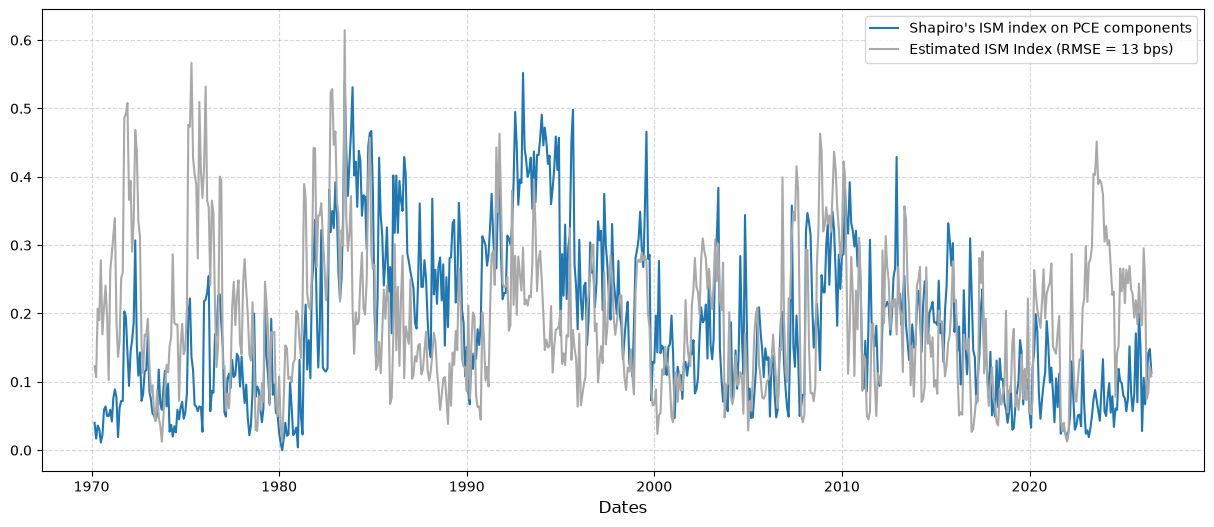

In [10]:
# Compare headline negative series 
AllSeries = negIsmi.to_frame().merge(
    ShapiroResults["ismi_headline_negative_ar1_k3"],
    how="left",
    right_index=True,
    left_index=True
)

# Compute RMSE
RMSE = utils.rmse(AllSeries["ismi_headline_negative_ar1_k3"].values, AllSeries["ISMI-"].values)

fig, ax = plt.subplots(figsize=(15, 6))
x_axis = AllSeries.index
ax.plot(
    x_axis,
    AllSeries["ismi_headline_negative_ar1_k3"].values,
    # color="orange",
    label="Shapiro's ISM index on PCE components",
    linewidth=1.5,
)

ax.plot(
    x_axis,
    AllSeries["ISMI-"].values,
    label=f"Estimated ISM Index (RMSE = {RMSE*100:.0f} bps)",
    color="darkgrey",
    linewidth=1.5,
)

ax.legend()
ax.set_xlabel("Dates", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

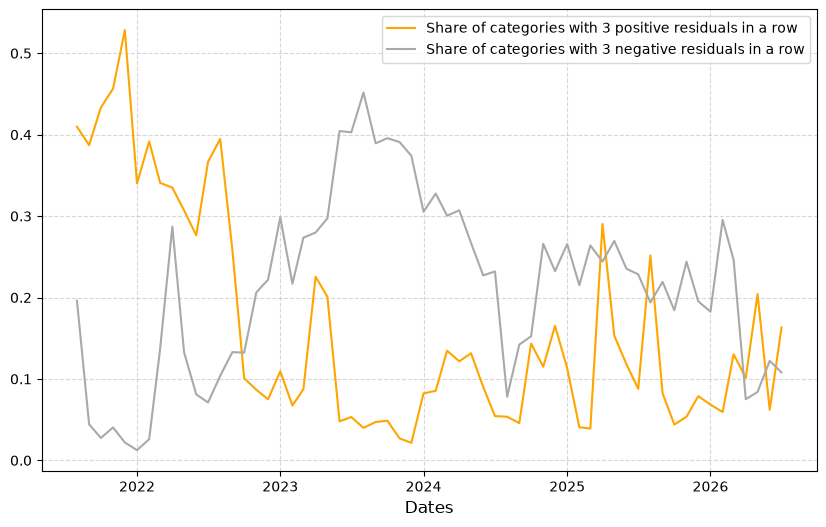

In [11]:
# Positive and negative contributions (5 last years)
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = posIsmi.index[-12*5:]
ax.plot(
    x_axis,
    posIsmi.values[-12*5:],
    color="orange",
    label="Share of categories with 3 positive residuals in a row",
    linewidth=1.5,
)

ax.plot(
    x_axis,
    negIsmi.values[-12*5:],
    label="Share of categories with 3 negative residuals in a row",
    color="darkgrey",
    linewidth=1.5,
)

ax.legend()
ax.set_xlabel("Dates", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

In [12]:
# Réplication Figure A1
df_shocks, aCoef, rhoCoef = fismi.twoStepsAr(InflTot)

# Drop NaN and merge
PCE = InflTot.copy()
PCE["Shocks"] = df_shocks.values
PCE["A"] = aCoef.values
PCE["Rho"] = rhoCoef.values
PCE = PCE.dropna()

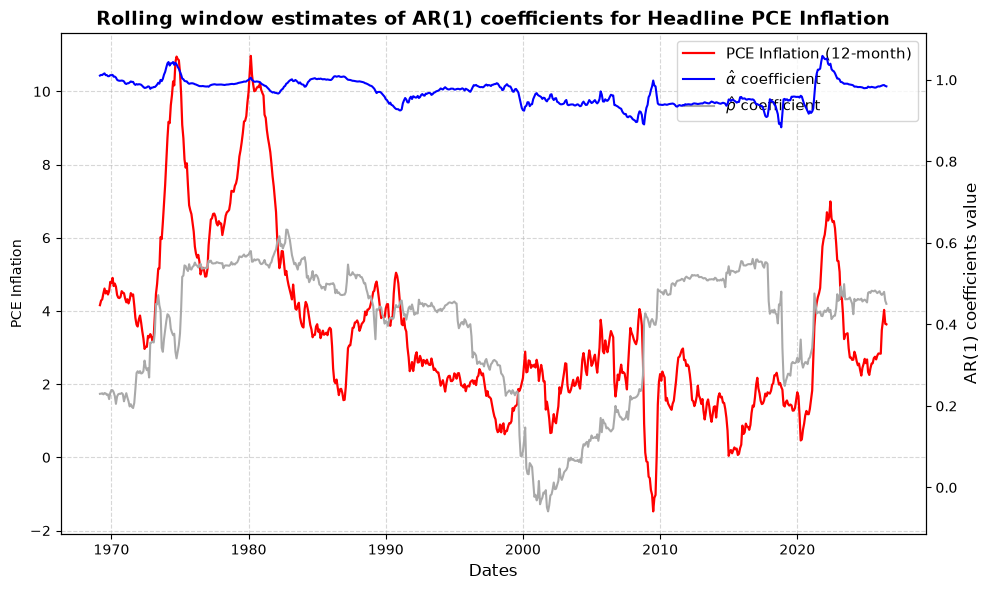

In [13]:
# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (HICP inflation - 12-month) ---
ax1.plot(
    PCE["Personal consumption expenditures"]*100,
    label="PCE Inflation (12-month)",
    color="red",
    linewidth=1.6,
)

ax1.set_xlabel("Dates", fontsize=12)
ax1.set_ylabel("PCE Inflation")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Right axis (AR coefficients) ---
ax2 = ax1.twinx()

ax2.plot(
    PCE["A"],
    label=r'$\hat \alpha$ coefficient',
    color="blue",
    linewidth=1.5,
)

ax2.plot(
    PCE["Rho"],
    label=r'$\hat \rho$ coefficient',
    color="darkgrey",
    linewidth=1.5,
)

ax2.set_ylabel("AR(1) coefficients value", fontsize=12)
ax2.tick_params(axis="y")

# --- Title, legend ---
plt.title("Rolling window estimates of AR(1) coefficients for Headline PCE Inflation", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=11)

plt.tight_layout()
plt.show()